In [1]:
import numpy as np
import matplotlib.pyplot as plt
from coffea.util import load
import hist
import mplhep as hep
from pocket_coffea.utils.plot_utils import PlotManager

In [2]:
#filename = "/work/mmarcheg/BTVNanoCommissioning/output/pocket_coffea/ggH_proxy/ggH_proxy_2017UL_VJets_v03/output_all.coffea"
#filename = "/work/mmarcheg/BTVNanoCommissioning/output/pocket_coffea/ggH_proxy/ggH_proxy_2018UL_flavorfix/output_all.coffea"
filename = "/work/mmarcheg/BTVNanoCommissioning/output/pocket_coffea/ggH_proxy/ggH_proxy_2018UL_tau21/output_all.coffea"
year = "2018"
o = load(filename)
o.keys()

dict_keys(['sum_genweights', 'sumw', 'cutflow', 'variables', 'columns', 'processing_metadata', 'seed_fatjet_chunk'])

In [3]:
o['variables'].keys()

dict_keys(['MuonGood_eta_1', 'MuonGood_pt_1', 'MuonGood_phi_1', 'MuonGood_eta_2', 'MuonGood_pt_2', 'MuonGood_phi_2', 'FatJetGood_eta', 'FatJetGood_pt', 'FatJetGood_phi', 'FatJetGood_mass', 'FatJetGood_msoftdrop', 'FatJetGood_tau21', 'FatJetGood_btagDDBvLV2', 'FatJetGood_btagDDCvLV2', 'FatJetGood_btagDDCvBV2', 'FatJetGood_particleNetMD_Xbb_QCD', 'FatJetGood_particleNetMD_Xcc_QCD', 'FatJetGood_deepTagMD_ZHbbvsQCD', 'FatJetGood_deepTagMD_ZHccvsQCD', 'FatJetGood_btagHbb', 'FatJetGood_eta_1', 'FatJetGood_pt_1', 'FatJetGood_phi_1', 'FatJetGood_mass_1', 'FatJetGood_msoftdrop_1', 'FatJetGood_tau21_1', 'FatJetGood_btagDDBvLV2_1', 'FatJetGood_btagDDCvLV2_1', 'FatJetGood_btagDDCvBV2_1', 'FatJetGood_particleNetMD_Xbb_QCD_1', 'FatJetGood_particleNetMD_Xcc_QCD_1', 'FatJetGood_deepTagMD_ZHbbvsQCD_1', 'FatJetGood_deepTagMD_ZHccvsQCD_1', 'FatJetGood_btagHbb_1', 'FatJetGood_eta_2', 'FatJetGood_pt_2', 'FatJetGood_phi_2', 'FatJetGood_mass_2', 'FatJetGood_msoftdrop_2', 'FatJetGood_tau21_2', 'FatJetGood_bta

In [4]:
from copy import deepcopy

signal = "GluGluH"

def map_flavor(h_dict):
    d = {'l' : [], 'c' : [], 'b' : []}
    for sample in h_dict.keys():
        for flavor in d.keys():
            if sample.endswith(flavor):
                if not sample.startswith(signal):
                    d[flavor].append(sample)
    return d

In [5]:
from config.ggH_proxy.style_cfg import style_ggh

files = {
    #"2017" : "/work/mmarcheg/BTVNanoCommissioning/output/pocket_coffea/ggH_proxy/ggH_proxy_2017UL_flavorfix/output_all.coffea",
    "2018" : "/work/mmarcheg/BTVNanoCommissioning/output/pocket_coffea/ggH_proxy/ggH_proxy_2018UL_tau21/output_all.coffea"
}

exclude = ["FatJetGood_tau21_p", "FatJetGood_tau21_btag", "FatJetGood_tau21_deep"]
only = ["FatJetGood_", "nFatJets"]
output = {}
for year, file in files.items():
    output[year] = load(file)

hist_cfg = {k : o["variables"][k] for k in o["variables"].keys() if (not any([e in k for e in exclude])) & (any([on in k for on in only]))}
hist_cfg.keys()

dict_keys(['FatJetGood_eta', 'FatJetGood_pt', 'FatJetGood_phi', 'FatJetGood_mass', 'FatJetGood_msoftdrop', 'FatJetGood_tau21', 'FatJetGood_btagDDBvLV2', 'FatJetGood_btagDDCvLV2', 'FatJetGood_btagDDCvBV2', 'FatJetGood_particleNetMD_Xbb_QCD', 'FatJetGood_particleNetMD_Xcc_QCD', 'FatJetGood_deepTagMD_ZHbbvsQCD', 'FatJetGood_deepTagMD_ZHccvsQCD', 'FatJetGood_btagHbb', 'FatJetGood_eta_1', 'FatJetGood_pt_1', 'FatJetGood_phi_1', 'FatJetGood_mass_1', 'FatJetGood_msoftdrop_1', 'FatJetGood_tau21_1', 'FatJetGood_btagDDBvLV2_1', 'FatJetGood_btagDDCvLV2_1', 'FatJetGood_btagDDCvBV2_1', 'FatJetGood_particleNetMD_Xbb_QCD_1', 'FatJetGood_particleNetMD_Xcc_QCD_1', 'FatJetGood_deepTagMD_ZHbbvsQCD_1', 'FatJetGood_deepTagMD_ZHccvsQCD_1', 'FatJetGood_btagHbb_1', 'FatJetGood_eta_2', 'FatJetGood_pt_2', 'FatJetGood_phi_2', 'FatJetGood_mass_2', 'FatJetGood_msoftdrop_2', 'FatJetGood_tau21_2', 'FatJetGood_btagDDBvLV2_2', 'FatJetGood_btagDDCvLV2_2', 'FatJetGood_btagDDCvBV2_2', 'FatJetGood_particleNetMD_Xbb_QCD_2',

In [6]:
samples_map = map_flavor(hist_cfg["FatJetGood_pt"])
samples_map

{'l': ['VJets_l', 'QCD_MuEnriched_l'],
 'c': ['VJets_c', 'VJets_cc', 'QCD_MuEnriched_c', 'QCD_MuEnriched_cc'],
 'b': ['VJets_b', 'VJets_bb', 'QCD_MuEnriched_b', 'QCD_MuEnriched_bb']}

In [7]:
style_ggh["opts_mc"]

{'histtype': 'step', 'stack': False}

In [8]:
fontsize = 16
style_ggh["fontsize"] = fontsize
style_ggh["opts_mc"]["yerr"] = False
style_ggh["opts_mc"]

{'histtype': 'step', 'stack': False, 'yerr': False}

In [9]:
plotter = PlotManager(
    hist_cfg=hist_cfg,
    plot_dir="plots",
    style_cfg=style_ggh,
    #only_cat=[],
    #data_key=args.data_key,
    log=True,
    density=True,
    save=False
)

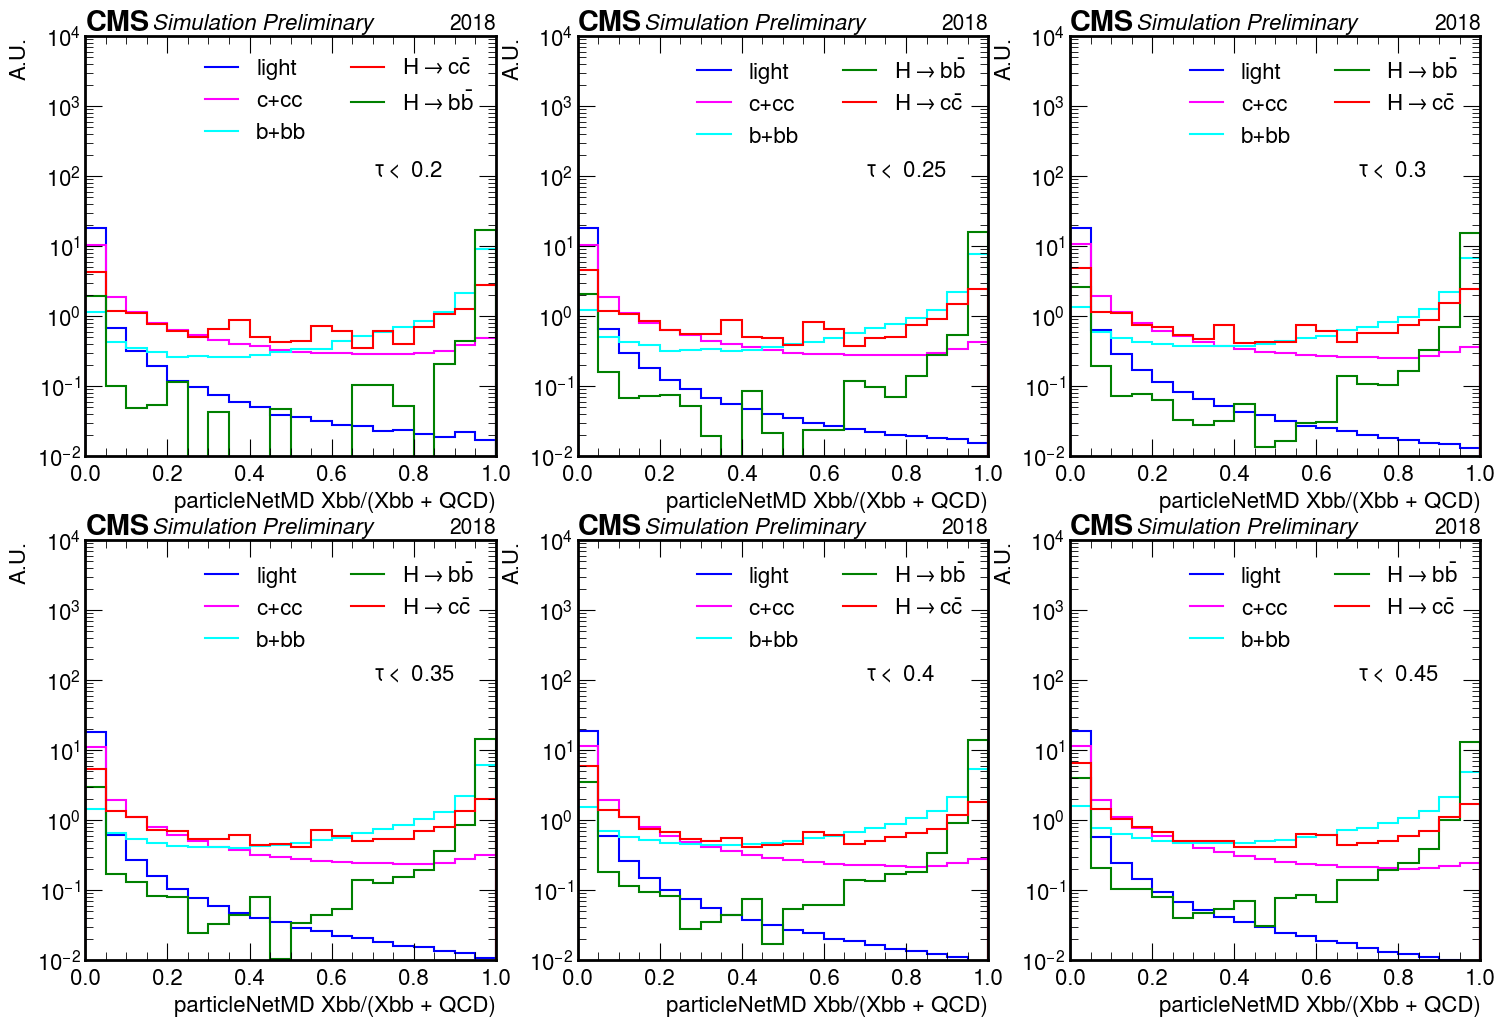

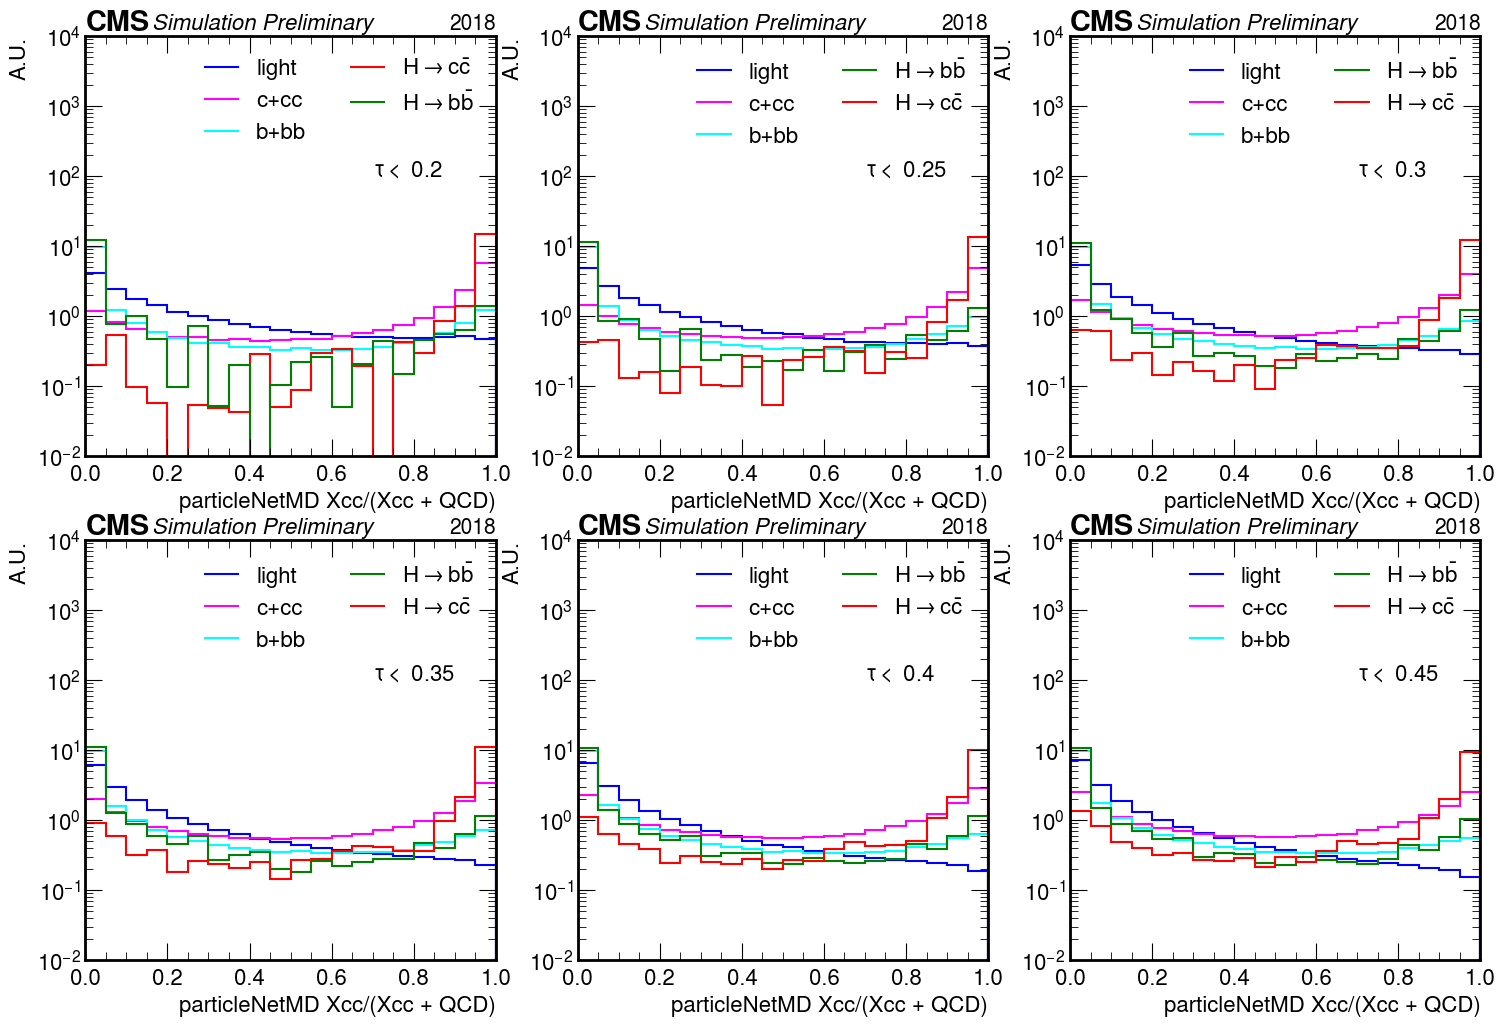

In [10]:
plt.style.use([hep.style.ROOT, {'font.size': fontsize}])
plt.rcParams.update({'font.size': fontsize})

#histname = "FatJetGood_particleNetMD_Xcc_QCD_40bins"
histnames = ["FatJetGood_particleNetMD_Xbb_QCD_20bins", "FatJetGood_particleNetMD_Xcc_QCD_20bins"]

for histname in histnames:
    shape = plotter.shape_objects[histname]
    categories = list(filter(lambda x : ('tau' in x) & (not 'mutag' in x) , shape.categories))
    fig, axes = plt.subplots(2, 3, figsize=(18, 12))
    axes_flat = axes.flatten()
    cut_tau21 = {cat : float(cat.split("tau")[-1])/100 for cat in categories if "tau" in cat}
    for i, cat in enumerate(categories):
        shape.build_stacks(year, cat)
        ax = axes_flat[i]
        hep.cms.text("Simulation Preliminary", fontsize=fontsize, loc=0, ax=ax)
        hep.cms.lumitext(text=f'{year}', fontsize=fontsize, ax=ax)
        shape.plot_mc(ax=ax)
        ax.text(0.7, 10**2, r"$\tau <$ " + f"{cut_tau21[cat]}", fontsize=fontsize)
        ax.set_ylim(0.01, 10**4)
    plt.savefig(f"plots/proxy/{histname}_tau21_scan.png", dpi=300)

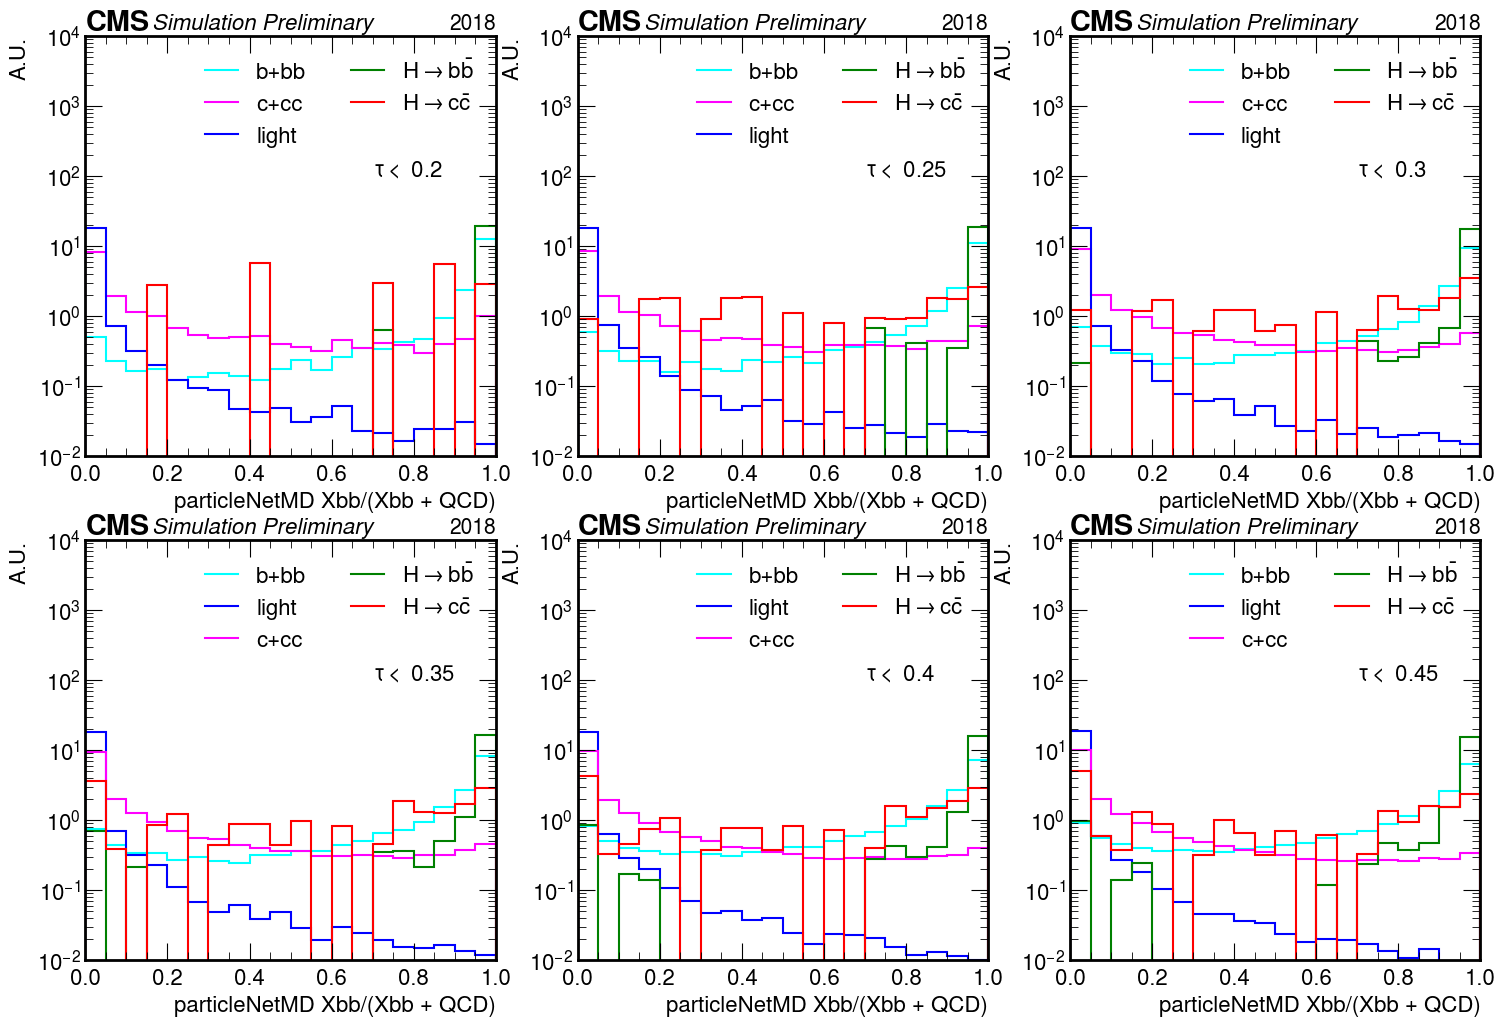

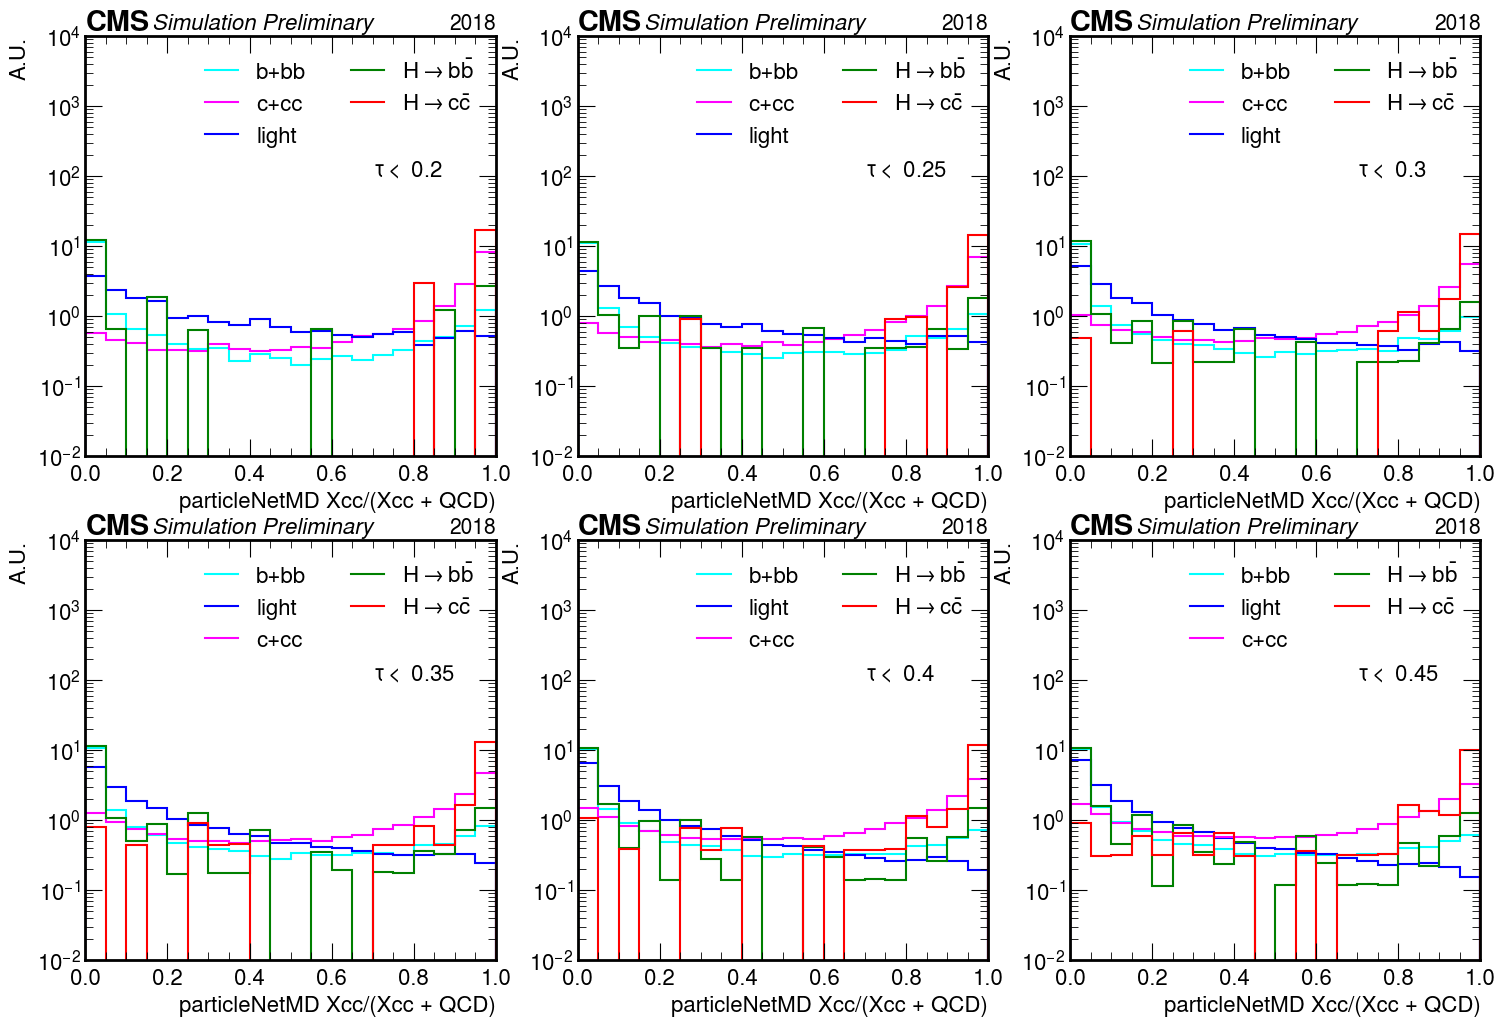

In [11]:
for histname in histnames:
    shape = plotter.shape_objects[histname]
    categories = list(filter(lambda x : ('tau' in x) & ('mutag' in x) , shape.categories))
    fig, axes = plt.subplots(2, 3, figsize=(18, 12))
    axes_flat = axes.flatten()
    cut_tau21 = {cat : float(cat.split("tau")[-1].split("_mutag")[0])/100 for cat in categories if "tau" in cat}
    for i, cat in enumerate(categories):
        shape.build_stacks(year, cat)
        ax = axes_flat[i]
        hep.cms.text("Simulation Preliminary", fontsize=fontsize, loc=0, ax=ax)
        hep.cms.lumitext(text=f'{year}', fontsize=fontsize, ax=ax)
        shape.plot_mc(ax=ax)
        ax.text(0.7, 10**2, r"$\tau <$ " + f"{cut_tau21[cat]}", fontsize=fontsize)
        ax.set_ylim(0.01, 10**4)
    plt.savefig(f"plots/proxy/{histname}_tau21_scan_mutag.png", dpi=300)

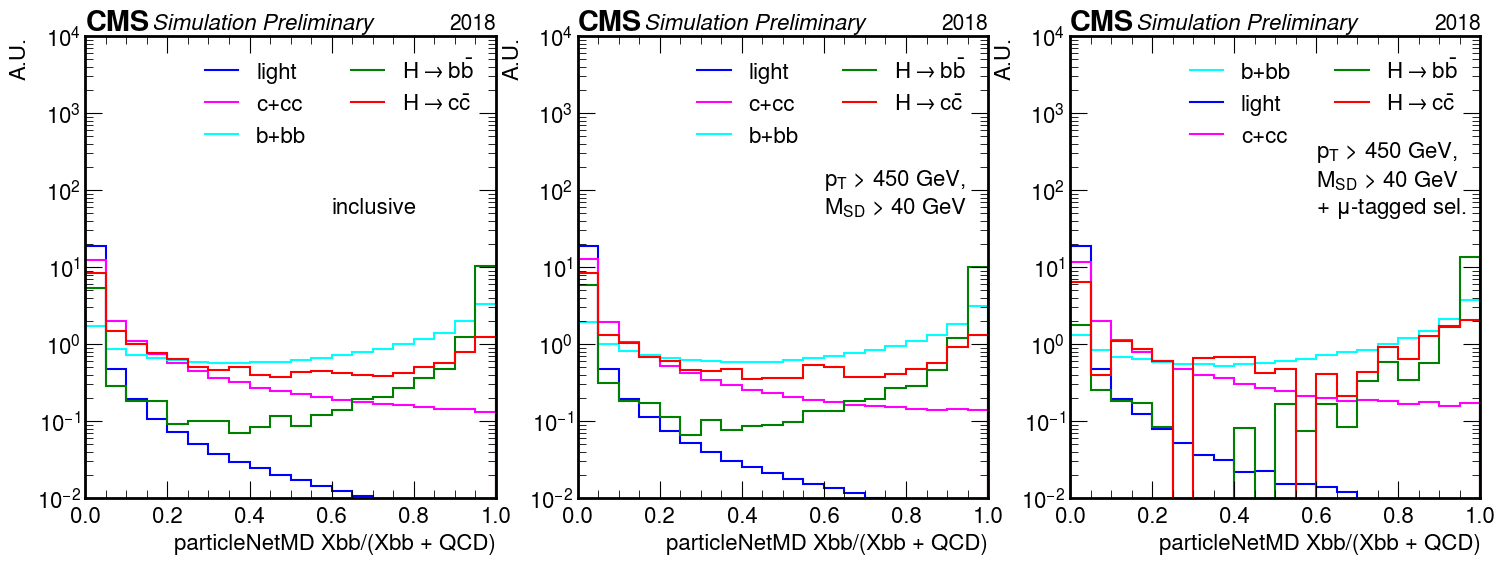

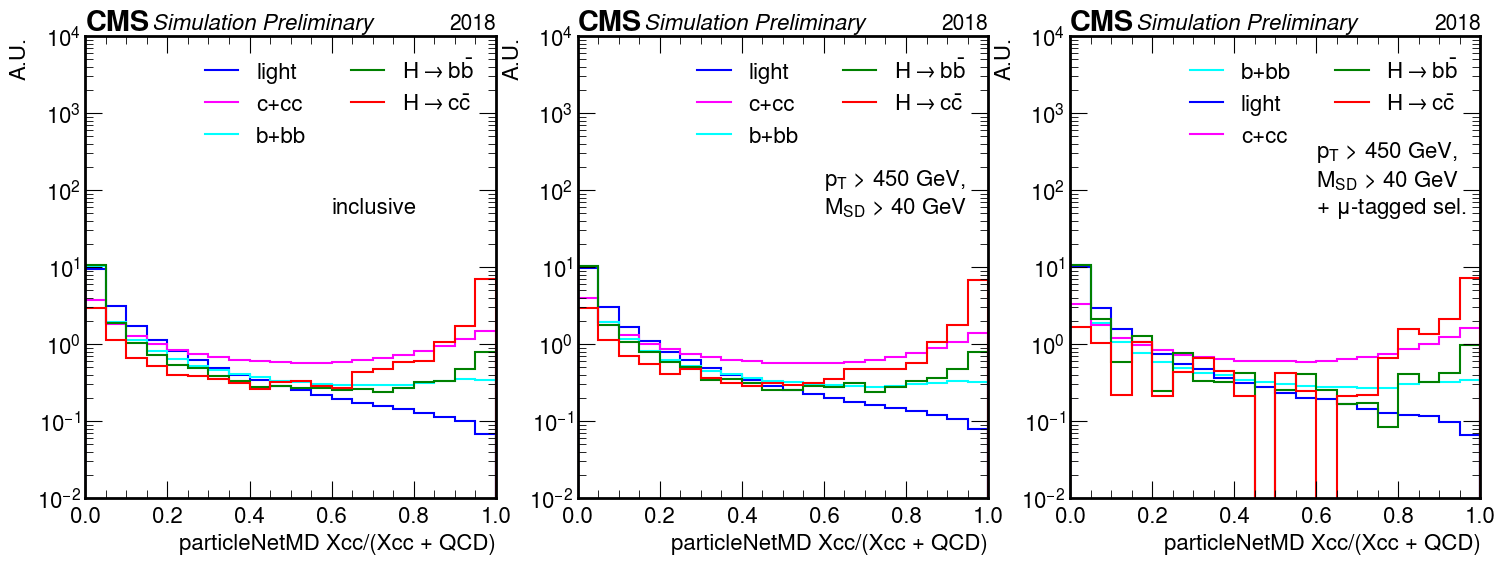

In [12]:
cut = {"inclusive" : "inclusive", "pt450msd40" : r"$p_T$ > 450 GeV,"+"\n"+"$M_{SD}$ > 40 GeV", "pt450msd40_mutag" : r"$p_T$ > 450 GeV,"+"\n"+"$M_{SD}$ > 40 GeV"+"\n"+r"+ $\mu$-tagged sel."}
for histname in histnames:
    shape = plotter.shape_objects[histname]
    categories = list(filter(lambda x : ('tau' not in x) , shape.categories))
    fig, axes = plt.subplots(1, 3, figsize=(18, 6))
    axes_flat = axes.flatten()
    for i, cat in enumerate(categories):
        shape.build_stacks(year, cat)
        ax = axes_flat[i]
        hep.cms.text("Simulation Preliminary", fontsize=fontsize, loc=0, ax=ax)
        hep.cms.lumitext(text=f'{year}', fontsize=fontsize, ax=ax)
        shape.plot_mc(ax=ax)
        ax.text(0.6, 0.5*10**2, f"{cut[cat]}", fontsize=fontsize)
        ax.set_ylim(0.01, 10**4)
    #plt.savefig(f"plots/proxy/{histname}_categories_comparison.png", dpi=300)

In [22]:
cut_tau21

{'pt450msd40tau20_mutag': 0.2,
 'pt450msd40tau25_mutag': 0.25,
 'pt450msd40tau30_mutag': 0.3,
 'pt450msd40tau35_mutag': 0.35,
 'pt450msd40tau40_mutag': 0.4,
 'pt450msd40tau45_mutag': 0.45}

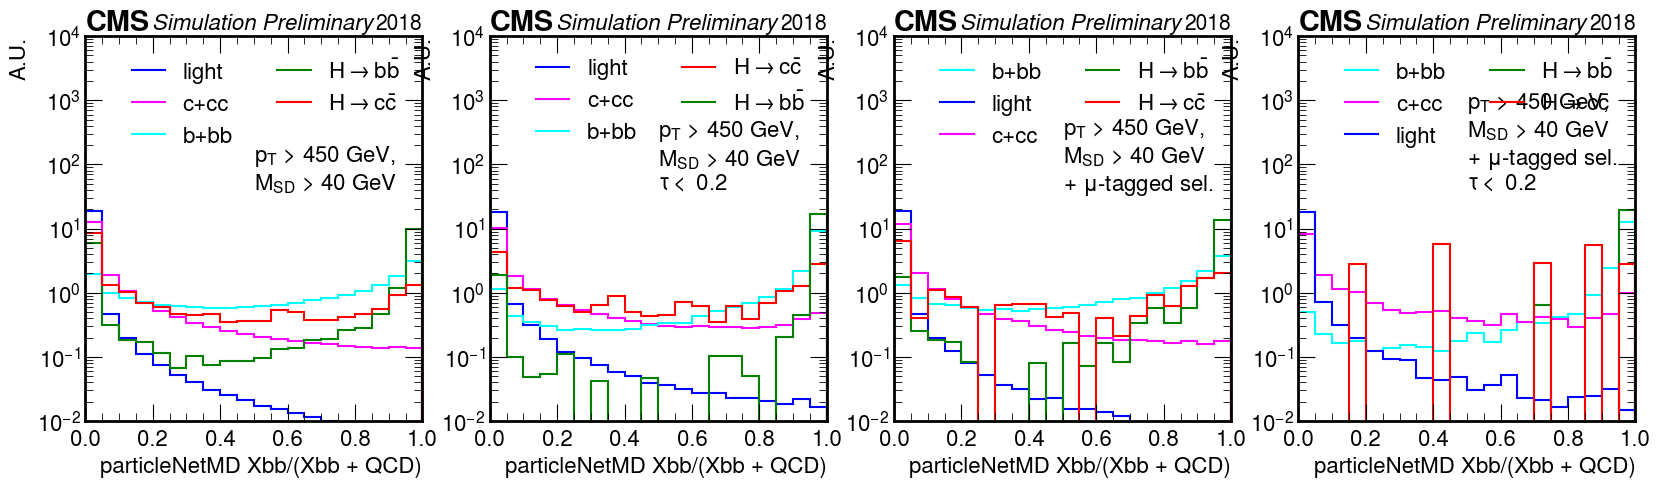

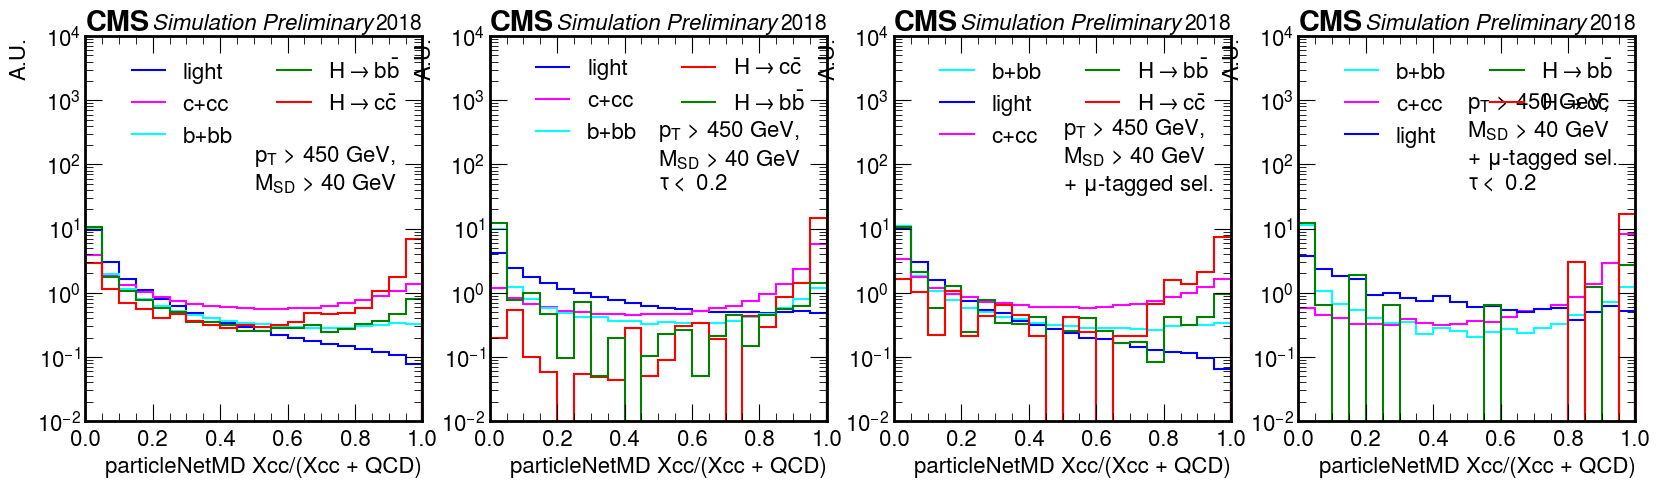

In [25]:
cut_tau21 ={ 'pt450msd40tau20_mutag': 0.2,
             'pt450msd40tau25_mutag': 0.25,
             'pt450msd40tau30_mutag': 0.3,
             'pt450msd40tau35_mutag': 0.35,
             'pt450msd40tau40_mutag': 0.4,
             'pt450msd40tau45_mutag': 0.45,
             'pt450msd40tau20': 0.2,
             'pt450msd40tau25': 0.25,
             'pt450msd40tau30': 0.3,
             'pt450msd40tau35': 0.35,
             'pt450msd40tau40': 0.4,
             'pt450msd40tau45': 0.45
           }
cut = {"pt450msd40" : r"$p_T$ > 450 GeV,"+"\n"+"$M_{SD}$ > 40 GeV", "pt450msd40_mutag" : r"$p_T$ > 450 GeV,"+"\n"+"$M_{SD}$ > 40 GeV"+"\n"+r"+ $\mu$-tagged sel."}
cut_new = deepcopy(cut)
for k, text in cut.items():
    cut_new[k.replace("msd40", "msd40tau20")] = text + "\n" + r"$\tau <$ " + f'{cut_tau21[k.replace("msd40", "msd40tau20")]}'
categories = ["pt450msd40", "pt450msd40tau20", "pt450msd40_mutag", "pt450msd40tau20_mutag"]
for histname in histnames:
    shape = plotter.shape_objects[histname]
    fig, axes = plt.subplots(1, 4, figsize=(20, 5))
    axes_flat = axes.flatten()
    for i, cat in enumerate(categories):
        shape.build_stacks(year, cat)
        ax = axes_flat[i]
        hep.cms.text("Simulation Preliminary", fontsize=fontsize, loc=0, ax=ax)
        hep.cms.lumitext(text=f'{year}', fontsize=fontsize, ax=ax)
        shape.plot_mc(ax=ax)
        ax.text(0.5, 0.4*10**2, f"{cut_new[cat]}", fontsize=fontsize)
        ax.set_ylim(0.01, 10**4)
    plt.savefig(f"plots/proxy/{histname}_categories_comparison.png", dpi=300)

In [ ]:
from copy import deepcopy

style_ggh_stacked = deepcopy(style_ggh)
style_ggh_stacked["opts_mc"]["stack"] = True
style_ggh_stacked["opts_mc"]["histtype"] = "fill"

plotter_linear = PlotManager(
    hist_cfg=hist_cfg,
    plot_dir="plots",
    style_cfg=style_ggh_stacked,
    #only_cat=[],
    #data_key=args.data_key,
    log=False,
    density=False,
    save=False
)

shape_tau21 = plotter_linear.shape_objects["FatJetGood_tau21"]
shape_tau21.build_stacks(year, "pt450msd40")
shape_tau21.define_figure(year, ratio=False)
shape_tau21.plot_mc()
plt.savefig("")

In [ ]:
cut = {"inclusive" : "inclusive", "pt450msd40" : r"$p_T$ > 450 GeV,"+"\n"+"$M_{SD}$ > 40 GeV", "pt450msd40_mutag" : r"$p_T$ > 450 GeV,"+"\n"+"$M_{SD}$ > 40 GeV"+"\n"+r"+ $\mu$-tagged sel."}
shape_nFatJet = plotter_linear.shape_objects["nFatJets"]
fig, axes = plt.subplots(1,2,figsize=(16,6))
axes_flat = axes.flatten()
for i, cat in enumerate(["pt450msd40", "pt450msd40_mutag"]):
    shape_nFatJet.build_stacks(year, cat)
    ax = axes_flat[i]
    shape_nFatJet.plot_mc(ax=ax)
    hep.cms.text("Simulation Preliminary", fontsize=fontsize, loc=0, ax=ax)
    hep.cms.lumitext(text=f'{year}', fontsize=fontsize, ax=ax)
    ax.set_xlim(0,4);
    xmin, xmax = ax.get_xlim()
    ymin, ymax = ax.get_ylim()
    ax.text(0.6*xmax, 0.6*ymax, f"{cut[cat]}", fontsize=fontsize)
    #plt.ylim(0,1.5*10**6);
    njets_tot = sum(shape_nFatJet.stack_sum_mc_nominal.values())
    print(njets_tot)
plt.savefig("plots/proxy/nFatJets_mutag_comparison.png", dpi=300, format="png")

In [ ]:
style_ggh_density = deepcopy(style_ggh)
style_ggh_density["opts_mc"]["stack"] = False
style_ggh_density["opts_mc"]["histtype"] = "step"

plotter_linear = PlotManager(
    hist_cfg=hist_cfg,
    plot_dir="plots",
    style_cfg=style_ggh_density,
    #only_cat=[],
    #data_key=args.data_key,
    log=False,
    density=True,
    save=False
)

shape_tau21 = plotter_linear.shape_objects["FatJetGood_tau21"]
fig, axes = plt.subplots(1,2,figsize=(16,6))
axes_flat = axes.flatten()
for i, cat in enumerate(["pt450msd40", "pt450msd40_mutag"]):
    shape_tau21.build_stacks(year, cat)
    ax = axes_flat[i]
    shape_tau21.plot_mc(ax=ax)    
    hep.cms.text("Simulation Preliminary", fontsize=fontsize, loc=0, ax=ax)
    hep.cms.lumitext(text=f'{year}', fontsize=fontsize, ax=ax)
    xmin, xmax = ax.get_xlim()
    ymin, ymax = ax.get_ylim()
    ax.text(0.6*xmax, 0.6*ymax, f"{cut[cat]}", fontsize=fontsize)
plt.savefig("plots/proxy/FatJetGood_tau21_density.png", dpi=300, format="png")

In [ ]:
n_events_twojets = shape_nFatJet.stack_sum_mc_nominal.values()[2]
n_events_twojets

In [ ]:
extra_jets_included = n_events_twojets/2
extra_jets_included

In [ ]:
qcd = o["cutflow"]["pt450msd40"]["QCD_MuEnriched"]
vjets = o["cutflow"]["pt450msd40"]["VJets"]
nmc = qcd + vjets
nmc

In [ ]:
qcd = o["cutflow"]["pt450msd40_mutag"]["QCD_MuEnriched"]
vjets = o["cutflow"]["pt450msd40_mutag"]["VJets"]
nmc_mutag = qcd + vjets
nmc_mutag

In [ ]:
eff = nmc_mutag / nmc
eff